In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Cargar datos

df = pd.read_csv("DatosAutomovilesFinal.csv")

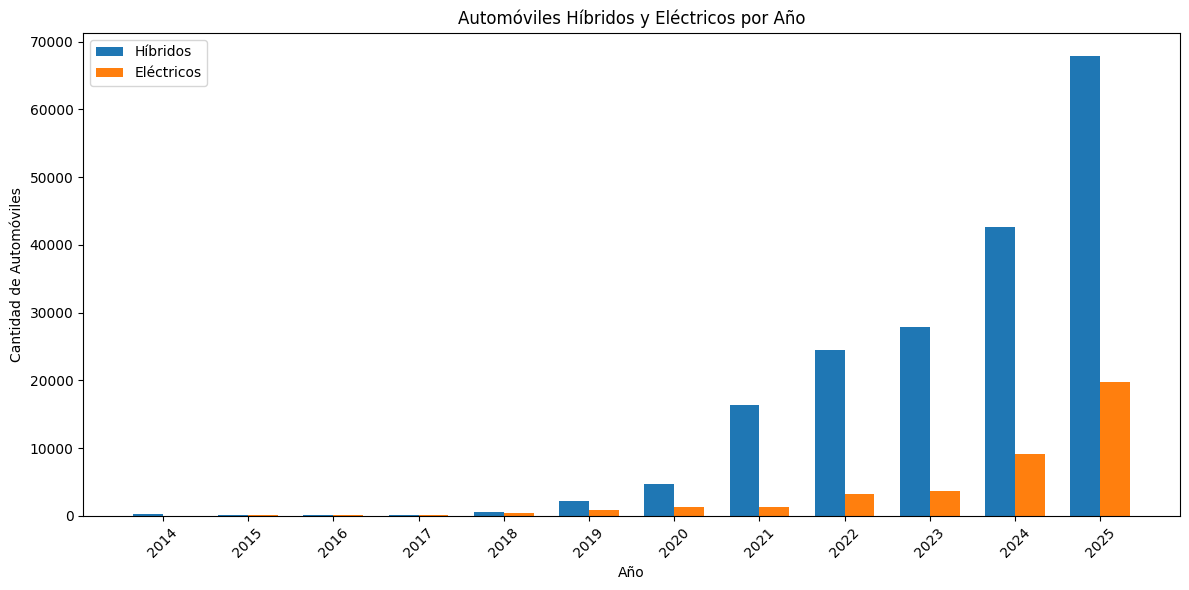

In [13]:
# Agrupar por Año y Tipo
resumen = (
    df.groupby(["Año", "Tipo"])
      .size()
      .unstack(fill_value=0)
      .sort_index()
)


# Crear gráfica de barras
años = resumen.index.astype(str)
x = np.arange(len(años))
width = 0.35

fig, ax = plt.subplots(figsize=(12,6))

ax.bar(x - width/2, resumen["Hibrido"], width, label="Híbridos")
ax.bar(x + width/2, resumen["Electrico"], width, label="Eléctricos")

ax.set_xlabel("Año")
ax.set_ylabel("Cantidad de Automóviles")
ax.set_title("Automóviles Híbridos y Eléctricos por Año")
ax.set_xticks(x)
ax.set_xticklabels(años, rotation=45)

ax.legend()

plt.tight_layout()
plt.show()


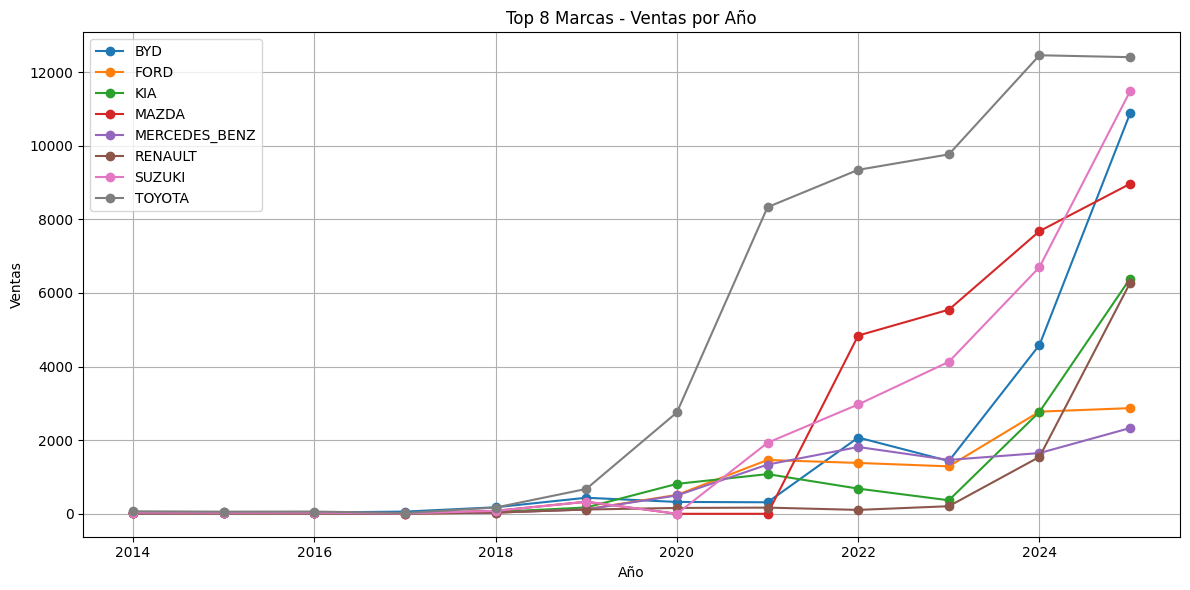

In [14]:
# Calcular ventas totales por marca
ventas_totales = df.groupby("Marca").size().sort_values(ascending=False)

top8_marcas = ventas_totales.head(8).index


# 3. Crear tabla Marca x Año
tabla = (
    df[df["Marca"].isin(top8_marcas)]
    .groupby(["Marca", "Año"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

# Graficar ventas por año para top 8 marcas
plt.figure(figsize=(12,6))

for marca in tabla.index:
    plt.plot(tabla.columns, tabla.loc[marca], marker='o', label=marca)

plt.xlabel("Año")
plt.ylabel("Ventas")
plt.title("Top 8 Marcas - Ventas por Año")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()


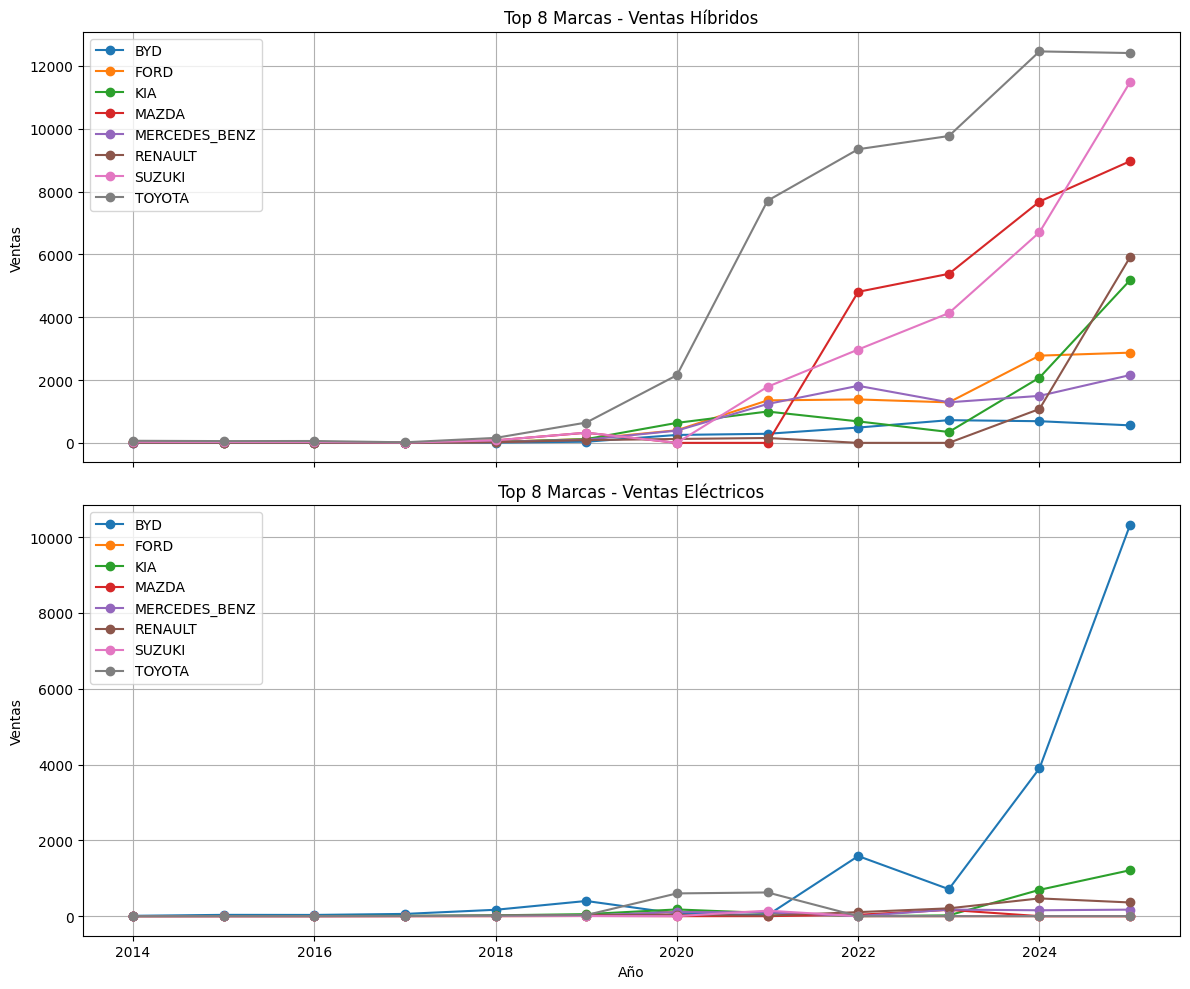

In [15]:
#  Obtener Top 8 marcas globales
ventas_totales = df.groupby("Marca").size().sort_values(ascending=False)
top8_marcas = ventas_totales.head(8).index


# Crear tablas separadas de hibridos y electricos
df_top = df[df["Marca"].isin(top8_marcas)]

tabla_h = (
    df_top[df_top["Tipo"]=="Hibrido"]
    .groupby(["Marca","Año"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)

tabla_e = (
    df_top[df_top["Tipo"]=="Electrico"]
    .groupby(["Marca","Año"])
    .size()
    .unstack(fill_value=0)
    .sort_index(axis=1)
)


# Graficar

fig, axes = plt.subplots(2, 1, figsize=(12,10), sharex=True)

# ---- HIBRIDOS ----
for marca in tabla_h.index:
    axes[0].plot(tabla_h.columns, tabla_h.loc[marca], marker='o', label=marca)

axes[0].set_title("Top 8 Marcas - Ventas Híbridos")
axes[0].set_ylabel("Ventas")
axes[0].grid(True)
axes[0].legend()

# ---- ELECTRICOS ----
for marca in tabla_e.index:
    axes[1].plot(tabla_e.columns, tabla_e.loc[marca], marker='o', label=marca)

axes[1].set_title("Top 8 Marcas - Ventas Eléctricos")
axes[1].set_xlabel("Año")
axes[1].set_ylabel("Ventas")
axes[1].grid(True)
axes[1].legend()

plt.tight_layout()
plt.show()


In [16]:
#  Tabla Marca x Año
tabla = (
    df.groupby(["Marca", "Año"])
      .size()
      .unstack(fill_value=0)
      .sort_index(axis=1)   # ordenar años
)
tabla

Año,2014,2015,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
Marca,,,,,,,,,,,,
AUDI,7,8,10,5,14,48,44,538,710,696,707,623
BMW,5,7,7,7,27,82,259,454,516,778,1354,1900
BYD,13,37,35,60,177,436,322,313,2072,1434,4589,10884
CHANGAN,1,2,2,1,7,21,0,49,38,70,230,929
CHERY,3,3,3,4,16,44,0,0,0,0,398,2104
CHEVROLET,1,3,2,5,13,31,0,0,40,123,335,777
CUPRA,2,2,2,1,5,18,0,0,0,0,249,1288
DFSK,0,0,0,0,1,1,0,0,5,55,0,0
DONGFENG,0,2,2,3,10,24,15,120,280,286,168,200
